# Arctic Domain EDA

Explores the two representative grid tiles (`H1_V10`, `H1_V7`) across both SSP scenarios.  
**Goals:**
1. Confirm all files exist and variable names match `arctic_description.md`
2. Record shapes, coordinate names, and temporal ranges for every variable
3. Map NaN patterns (identify ocean pixels, data gaps)
4. Verify dynamic inputs share the same temporal resolution
5. Flag anything that requires a design decision before preprocessing

In [11]:
import sys
import warnings
from pathlib import Path

import gcsfs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore")

# Locate project root (contains CLAUDE.MD) regardless of where Jupyter is launched from
root = Path.cwd()
while root != root.parent and not (root / "CLAUDE.MD").exists():
    root = root.parent
if not (root / "CLAUDE.MD").exists():
    raise RuntimeError("Could not find project root â€” launch Jupyter from inside the repo.")
sys.path.insert(0, str(root))

from config.config import load_config
print("Project root:", root)

Project root: c:\Sandeep\Woodwell\Multi-domain-time-series


In [12]:
cfg = load_config("arctic_domain")

BUCKET         = cfg["gcs"]["bucket"]
EDA_GRIDS      = cfg["gcs"]["eda_grids"]
SCENARIOS      = cfg["scenarios"]
TARGET_SUB     = cfg["gcs"]["target_subfolder"]
STATIC_FILES   = cfg["inputs"]["static"]
DYN_TIME_FILES = cfg["inputs"]["dynamic_time_only"]
DYN_SPAT_FILES = cfg["inputs"]["dynamic_spatiotemporal"]
TARGETS        = cfg["targets"]

print(f"Bucket    : {BUCKET}")
print(f"EDA grids : {EDA_GRIDS}")
print(f"Scenarios : {SCENARIOS}")
print(f"Static    : {STATIC_FILES}")
print(f"Dyn-time  : {DYN_TIME_FILES}")
print(f"Dyn-spat  : {DYN_SPAT_FILES}")
print(f"Targets   : {[t['name'] for t in TARGETS]}")

Bucket    : gs://circumpolar-readonly/raw
EDA grids : ['H1_V10', 'H1_V7']
Scenarios : ['ssp1_2_6_mri_esm2_0', 'ssp5_8_5_mri_esm2_0']
Static    : ['soil-texture.nc', 'drainage.nc', 'fri-fire.nc', 'topo.nc', 'vegetation.nc']
Dyn-time  : ['co2.nc', 'projected-co2.nc']
Dyn-spat  : ['historic-climate.nc', 'projected-climate.nc', 'historic-explicit-fire.nc', 'projected-explicit-fire.nc']
Targets   : ['ALD', 'GPP', 'RECO', 'VEGC']


In [13]:
# GCS filesystem â€” uses application-default credentials
fs = gcsfs.GCSFileSystem(token="google_default")

bucket_bare = BUCKET.replace("gs://", "")
top = fs.ls(bucket_bare)
print(f"Top-level entries in bucket ({len(top)} found):")
for p in top[:10]:
    print(" ", p)
if len(top) > 10:
    print(f"  ... and {len(top) - 10} more")

Top-level entries in bucket (264 found):
  circumpolar-readonly/raw
  circumpolar-readonly/raw/H10_V10
  circumpolar-readonly/raw/H10_V11
  circumpolar-readonly/raw/H10_V14
  circumpolar-readonly/raw/H10_V15
  circumpolar-readonly/raw/H10_V16
  circumpolar-readonly/raw/H10_V17
  circumpolar-readonly/raw/H10_V18
  circumpolar-readonly/raw/H10_V19
  circumpolar-readonly/raw/H10_V9
  ... and 254 more


In [14]:
# ── Path helpers ──────────────────────────────────────────────────────────────

def input_gcs_path(grid: str, scenario: str, filename: str) -> str:
    return f"{BUCKET}/{grid}/{scenario}/{filename}"

def target_gcs_path(grid: str, scenario: str, filename: str) -> str:
    return f"{BUCKET}/{grid}/{scenario}_split/{TARGET_SUB}/{filename}"


# ── Open helper ───────────────────────────────────────────────────────────────

_time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

def open_nc(path: str) -> xr.Dataset:
    """Open a NetCDF from GCS. Handles NetCDF3 (scipy) and NetCDF4/HDF5 (h5netcdf).
    Raises FileNotFoundError if the path does not exist in GCS.
    """
    bare = path.replace("gs://", "")
    if not fs.exists(bare):
        raise FileNotFoundError(f"GCS path not found: {path}")
    last_exc: Exception = RuntimeError("No engine tried.")
    for engine in ("h5netcdf", "scipy"):
        try:
            with fs.open(path, "rb") as f:
                return xr.open_dataset(f, engine=engine, decode_times=_time_coder).load()
        except Exception as e:
            last_exc = e
            continue
    raise IOError(f"Could not open {path} with any engine.") from last_exc


# ── Inspect helper ────────────────────────────────────────────────────────────

def inspect_ds(ds: xr.Dataset, label: str) -> list[dict]:
    """Print a summary of a dataset and return metadata rows for the summary table."""
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"Dims   : {dict(ds.sizes)}")
    print(f"Coords : {list(ds.coords)}")

    time_range = (None, None)
    n_time = None
    if "time" in ds.coords:
        t = ds["time"].values
        time_range = (str(t[0])[:10], str(t[-1])[:10])
        n_time = len(t)
        print(f"Time   : {time_range[0]} -> {time_range[1]}  ({n_time} steps)")

    rows = []
    for var in ds.data_vars:
        da = ds[var]
        try:
            nan_frac = float(np.isnan(da.values.astype(float)).mean())
        except (TypeError, ValueError):
            nan_frac = float("nan")
        print(f"  [{var}]  dims={da.dims}  shape={da.shape}  dtype={da.dtype}  NaN={nan_frac:.3f}")
        rows.append({
            "label":       label,
            "variable":    var,
            "dims":        str(da.dims),
            "shape":       str(da.shape),
            "time_start":  time_range[0],
            "time_end":    time_range[1],
            "n_timesteps": n_time,
            "nan_frac":    round(nan_frac, 4),
        })
    return rows


summary_rows: list[dict] = []
flags: list[str] = []


## 1. Static Input Variables

Expected: spatial-only (no `time` dim).  
Checking all five static files for both EDA grids.

In [15]:
# Static files are not scenario-dependent â€” check under scenario[0].
scenario = SCENARIOS[0]

for grid in EDA_GRIDS:
    for fname in STATIC_FILES:
        path = input_gcs_path(grid, scenario, fname)
        try:
            ds = open_nc(path)
            rows = inspect_ds(ds, f"{grid} | {fname}")
            for r in rows:
                r["nature"] = "static"
            summary_rows.extend(rows)
            if "time" in ds.dims:
                flags.append(f"FLAG: {fname} in {grid} has a 'time' dim â€” expected static (space only).")
        except FileNotFoundError:
            msg = f"FLAG: {path} NOT FOUND â€” check bucket path."
            flags.append(msg)
            print(msg)


  H1_V10 | soil-texture.nc
Dims   : {'Y': 28, 'X': 32}
Coords : ['X', 'Y']
  [pct_clay]  dims=('Y', 'X')  shape=(28, 32)  dtype=float32  NaN=0.000
  [pct_silt]  dims=('Y', 'X')  shape=(28, 32)  dtype=float32  NaN=0.000
  [pct_sand]  dims=('Y', 'X')  shape=(28, 32)  dtype=float32  NaN=0.000
  [lambert_azimuthal_equal_area]  dims=()  shape=()  dtype=object  NaN=nan
  [lat]  dims=('Y', 'X')  shape=(28, 32)  dtype=float32  NaN=0.000
  [lon]  dims=('Y', 'X')  shape=(28, 32)  dtype=float32  NaN=0.000

  H1_V10 | drainage.nc
Dims   : {'Y': 28, 'X': 32}
Coords : ['X', 'Y']
  [drainage_class]  dims=('Y', 'X')  shape=(28, 32)  dtype=float64  NaN=0.000
  [lambert_azimuthal_equal_area]  dims=()  shape=()  dtype=object  NaN=nan
  [lat]  dims=('Y', 'X')  shape=(28, 32)  dtype=float32  NaN=0.000
  [lon]  dims=('Y', 'X')  shape=(28, 32)  dtype=float32  NaN=0.000

  H1_V10 | fri-fire.nc
Dims   : {'Y': 28, 'X': 32}
Coords : ['Y', 'X']
  [lat]  dims=('Y', 'X')  shape=(28, 32)  dtype=float32  NaN=0.000
 

## 2. Dynamic Time-Only Inputs (CO2)

Expected: `time` dimension only, no spatial dims.

In [16]:
# CO2 should be the same across grids â€” check a single grid, both scenarios.
grid = EDA_GRIDS[0]

for scenario in SCENARIOS:
    for fname in DYN_TIME_FILES:
        path = input_gcs_path(grid, scenario, fname)
        try:
            ds = open_nc(path)
            rows = inspect_ds(ds, f"{grid} | {scenario} | {fname}")
            for r in rows:
                r["nature"] = "dynamic-time-only"
            summary_rows.extend(rows)
            spatial_dims = [d for d in ds.dims if d != "time"]
            if spatial_dims:
                flags.append(f"FLAG: {fname} ({scenario}) has spatial dims {spatial_dims} â€” expected time-only.")
        except FileNotFoundError:
            msg = f"FLAG: {path} NOT FOUND."
            flags.append(msg)
            print(msg)


  H1_V10 | ssp1_2_6_mri_esm2_0 | co2.nc
Dims   : {'year': 124}
Coords : ['year']
  [co2]  dims=('year',)  shape=(124,)  dtype=float32  NaN=0.000

  H1_V10 | ssp1_2_6_mri_esm2_0 | projected-co2.nc
Dims   : {'year': 76}
Coords : ['year']
  [co2]  dims=('year',)  shape=(76,)  dtype=float32  NaN=0.000

  H1_V10 | ssp5_8_5_mri_esm2_0 | co2.nc
Dims   : {'year': 124}
Coords : ['year']
  [co2]  dims=('year',)  shape=(124,)  dtype=float32  NaN=0.000

  H1_V10 | ssp5_8_5_mri_esm2_0 | projected-co2.nc
Dims   : {'year': 76}
Coords : ['year']
  [co2]  dims=('year',)  shape=(76,)  dtype=float32  NaN=0.000


## 3. Dynamic Spatiotemporal Inputs (Climate & Fire)

Critical: all four files must share the same temporal resolution.  
Historical and projected periods must also join cleanly.

In [17]:
temporal_resolutions: dict[str, str] = {}

for grid in EDA_GRIDS:
    for scenario in SCENARIOS:
        for fname in DYN_SPAT_FILES:
            path = input_gcs_path(grid, scenario, fname)
            try:
                ds = open_nc(path)
                rows = inspect_ds(ds, f"{grid} | {scenario} | {fname}")
                for r in rows:
                    r["nature"] = "dynamic-spatiotemporal"
                summary_rows.extend(rows)

                if "time" in ds.coords and len(ds["time"]) > 1:
                    t = ds["time"].values
                    t0, t1 = t[0], t[1]
                    if hasattr(t0, "toordinal"):
                        delta_days = t1.toordinal() - t0.toordinal()
                    else:
                        delta_days = int((t1 - t0) / np.timedelta64(1, "D"))
                    if delta_days <= 1:
                        res = "daily"
                    elif delta_days <= 16:
                        res = "sub-monthly"
                    elif delta_days <= 31:
                        res = "monthly"
                    elif delta_days <= 92:
                        res = "seasonal"
                    else:
                        res = "yearly"
                    temporal_resolutions.setdefault(fname, res)
                    if temporal_resolutions[fname] != res:
                        flags.append(f"FLAG: {fname} inconsistent resolution across grids/scenarios.")
            except FileNotFoundError:
                msg = f"FLAG: {path} NOT FOUND."
                flags.append(msg)
                print(msg)



  H1_V10 | ssp1_2_6_mri_esm2_0 | historic-climate.nc
Dims   : {'time': 1488, 'Y': 28, 'X': 32}
Coords : ['time', 'Y', 'X']
Time   : 1901-01-01 -> 2024-12-01  (1488 steps)
  [tair]  dims=('time', 'Y', 'X')  shape=(1488, 28, 32)  dtype=float32  NaN=0.446
  [precip]  dims=('time', 'Y', 'X')  shape=(1488, 28, 32)  dtype=float32  NaN=0.446
  [nirr]  dims=('time', 'Y', 'X')  shape=(1488, 28, 32)  dtype=float32  NaN=0.446
  [vapor_press]  dims=('time', 'Y', 'X')  shape=(1488, 28, 32)  dtype=float32  NaN=0.446
  [lat]  dims=('Y', 'X')  shape=(28, 32)  dtype=float32  NaN=0.000
  [lon]  dims=('Y', 'X')  shape=(28, 32)  dtype=float32  NaN=0.000

  H1_V10 | ssp1_2_6_mri_esm2_0 | projected-climate.nc
Dims   : {'time': 912, 'Y': 28, 'X': 32}
Coords : ['time', 'Y', 'X']
Time   : 2025-01-01 -> 2100-12-01  (912 steps)
  [tair]  dims=('time', 'Y', 'X')  shape=(912, 28, 32)  dtype=float32  NaN=0.446
  [precip]  dims=('time', 'Y', 'X')  shape=(912, 28, 32)  dtype=float32  NaN=0.446
  [nirr]  dims=('time'

In [18]:
print("Temporal resolution per dynamic spatiotemporal file:")
all_res = set()
for key, res in temporal_resolutions.items():
    print(f"  {key}: {res}")
    all_res.add(res)

if len(all_res) > 1:
    msg = f"FLAG: Mixed temporal resolutions detected: {all_res}. Decision required before preprocessing."
    flags.append(msg)
    print(f"\n*** {msg} ***")
else:
    print(f"\nAll dynamic spatiotemporal inputs share resolution: {all_res.pop() if all_res else 'N/A'}")

Temporal resolution per dynamic spatiotemporal file:
  historic-climate.nc: monthly
  projected-climate.nc: monthly
  historic-explicit-fire.nc: yearly
  projected-explicit-fire.nc: yearly

*** FLAG: Mixed temporal resolutions detected: {'monthly', 'yearly'}. Decision required before preprocessing. ***


## 4. Target Variables

Expected: GPP and RECO monthly, ALD and VEGC yearly.  
Suffix `_tr` = historical, `_sc` = projected.

In [19]:
for grid in EDA_GRIDS:
    for scenario in SCENARIOS:
        for t in TARGETS:
            for period, fname in [("historical", t["historical"]), ("projected", t["projected"])]:
                path = target_gcs_path(grid, scenario, fname)
                try:
                    ds = open_nc(path)
                    rows = inspect_ds(ds, f"{grid} | {scenario} | {t['name']} ({period})")
                    for r in rows:
                        r["nature"] = f"target-{t['resolution']}"
                    summary_rows.extend(rows)
                except FileNotFoundError:
                    msg = f"FLAG: {path} NOT FOUND."
                    flags.append(msg)
                    print(msg)


  H1_V10 | ssp1_2_6_mri_esm2_0 | ALD (historical)
Dims   : {'time': 124, 'y': 28, 'x': 32}
Coords : ['time']
Time   : 1901-01-01 -> 2024-01-01  (124 steps)
  [ALD]  dims=('time', 'y', 'x')  shape=(124, 28, 32)  dtype=float64  NaN=0.446
  [lambert_azimuthal_equal_area]  dims=()  shape=()  dtype=|S1  NaN=nan

  H1_V10 | ssp1_2_6_mri_esm2_0 | ALD (projected)
Dims   : {'time': 76, 'y': 28, 'x': 32}
Coords : ['time']
Time   : 1901-01-01 -> 1976-01-01  (76 steps)
  [ALD]  dims=('time', 'y', 'x')  shape=(76, 28, 32)  dtype=float64  NaN=0.446
  [lambert_azimuthal_equal_area]  dims=()  shape=()  dtype=|S1  NaN=nan

  H1_V10 | ssp1_2_6_mri_esm2_0 | GPP (historical)
Dims   : {'time': 1488, 'y': 28, 'x': 32}
Coords : ['time']
Time   : 1901-01-01 -> 2024-12-01  (1488 steps)
  [GPP]  dims=('time', 'y', 'x')  shape=(1488, 28, 32)  dtype=float64  NaN=0.446
  [lambert_azimuthal_equal_area]  dims=()  shape=()  dtype=|S1  NaN=nan

  H1_V10 | ssp1_2_6_mri_esm2_0 | GPP (projected)
Dims   : {'time': 912, '

## 5. NaN Patterns â€” Visualization

### 5a. Static Inputs â€” Spatial NaN Maps

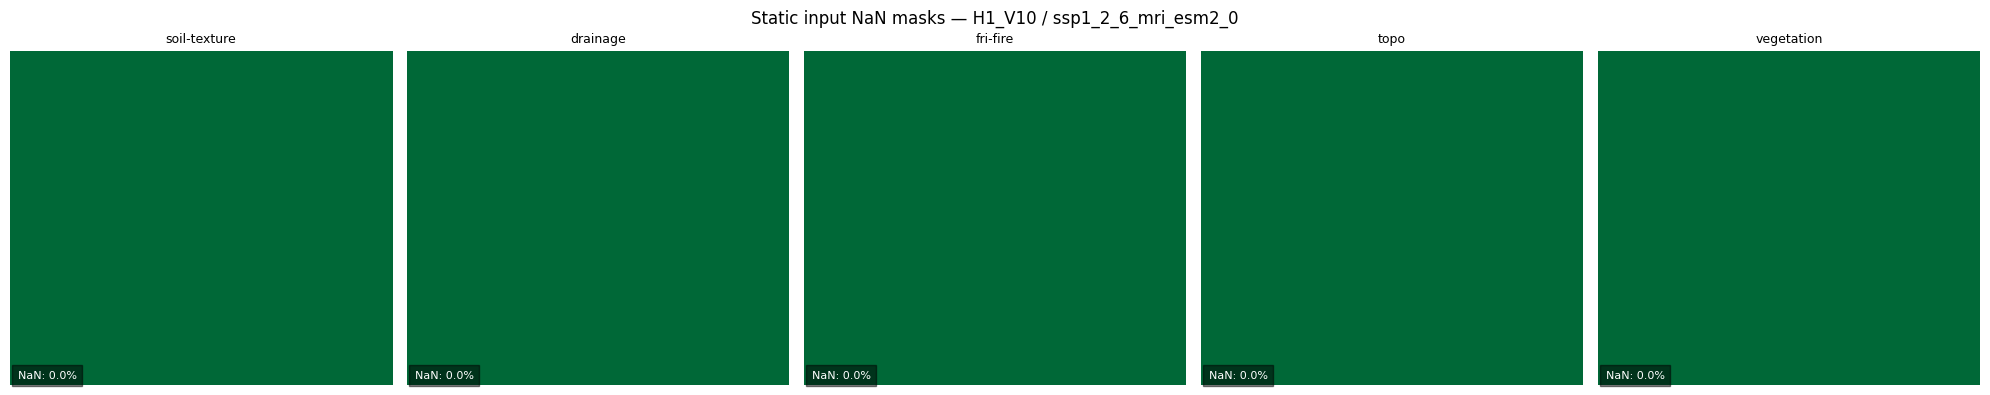

In [20]:
grid = EDA_GRIDS[0]
scenario = SCENARIOS[0]
n = len(STATIC_FILES)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
fig.suptitle(f"Static input NaN masks — {grid} / {scenario}", fontsize=12)
if n == 1:
    axes = [axes]

for ax, fname in zip(axes, STATIC_FILES):
    try:
        ds = open_nc(input_gcs_path(grid, scenario, fname))
        arr = None
        for vname in ds.data_vars:
            da = ds[vname]
            if da.ndim >= 2 and np.issubdtype(da.dtype, np.number):
                arr = da.values
                break
        if arr is None:
            ax.set_title(f"{fname.replace('.nc', '')}\n(no numeric 2D var)", fontsize=8)
            ax.axis("off")
            continue
        while arr.ndim > 2:
            arr = arr[0]
        mask = np.isnan(arr).astype(float)
        ax.imshow(mask, cmap="RdYlGn_r", vmin=0, vmax=1, origin="upper")
        ax.set_title(fname.replace(".nc", ""), fontsize=9)
        ax.axis("off")
        ax.text(0.02, 0.02, f"NaN: {mask.mean():.1%}", transform=ax.transAxes,
                fontsize=8, color="white", bbox=dict(fc="black", alpha=0.5))
    except Exception as e:
        ax.set_title(f"{fname}\nERROR", fontsize=8)
        print(f"Error: {e}")

plt.tight_layout()
plt.show()


### 5b. Dynamic Spatiotemporal â€” NaN Summary

For each variable: (left) fraction of time steps NaN per pixel | (right) fraction of pixels NaN per time step.

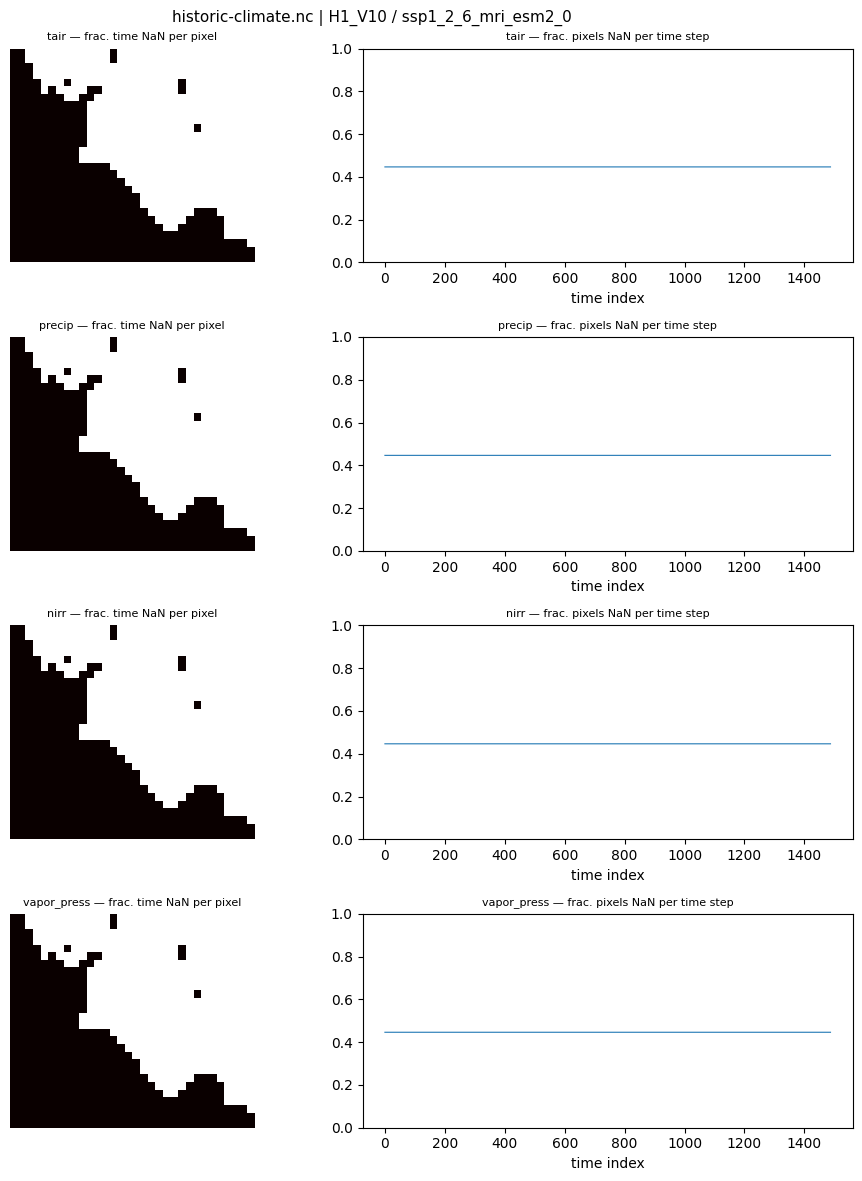

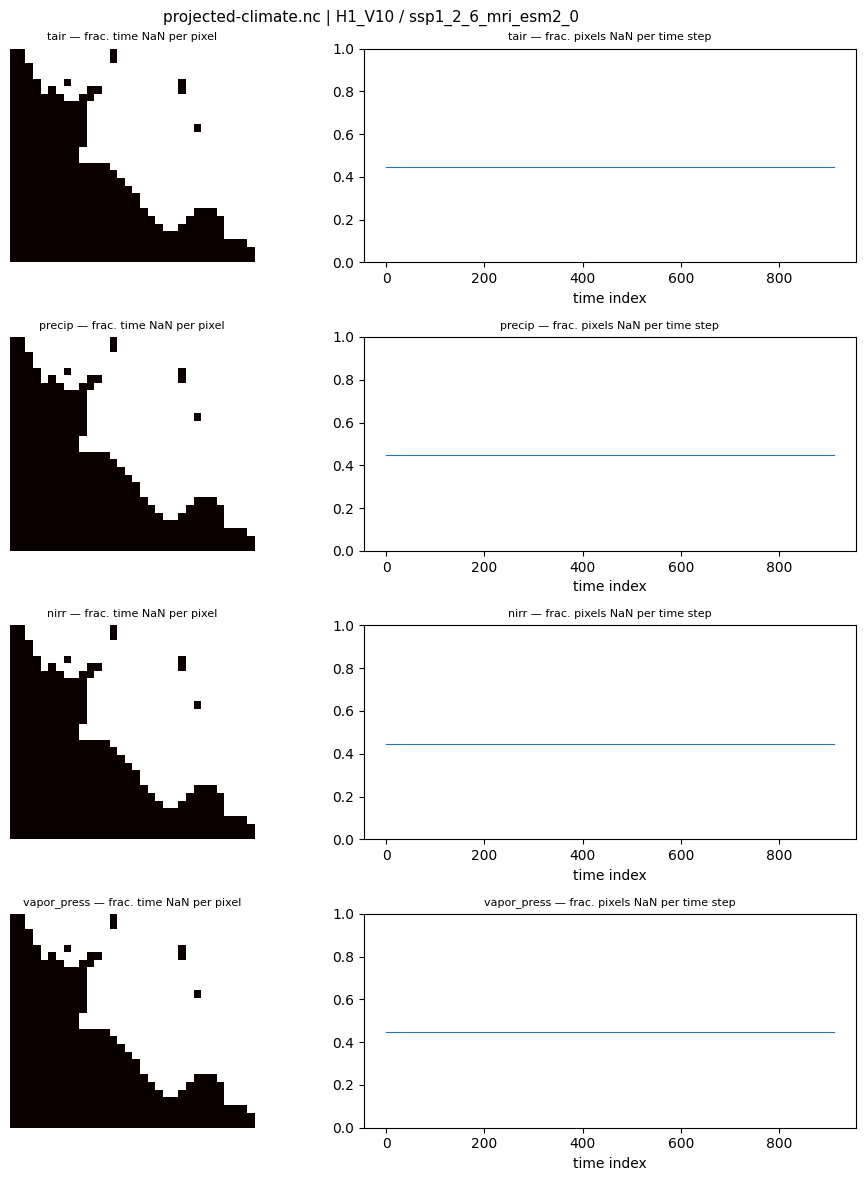

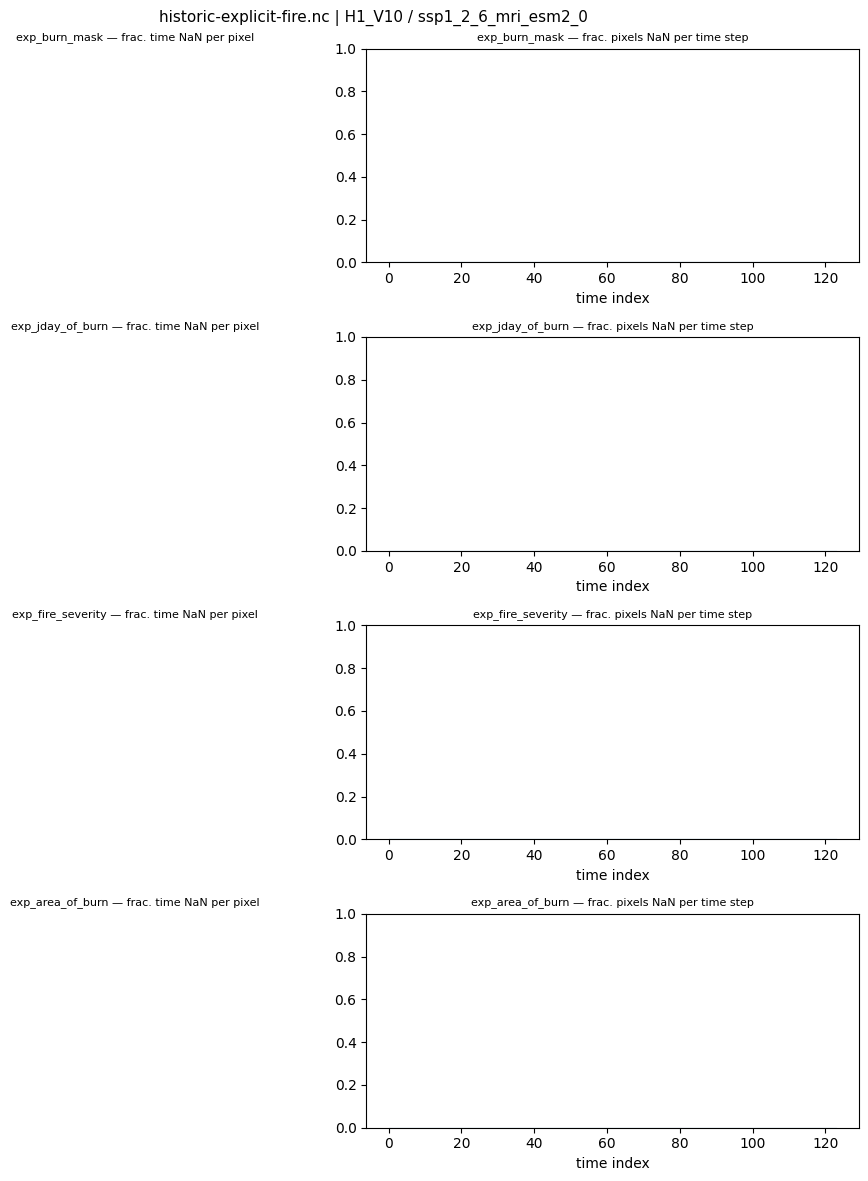

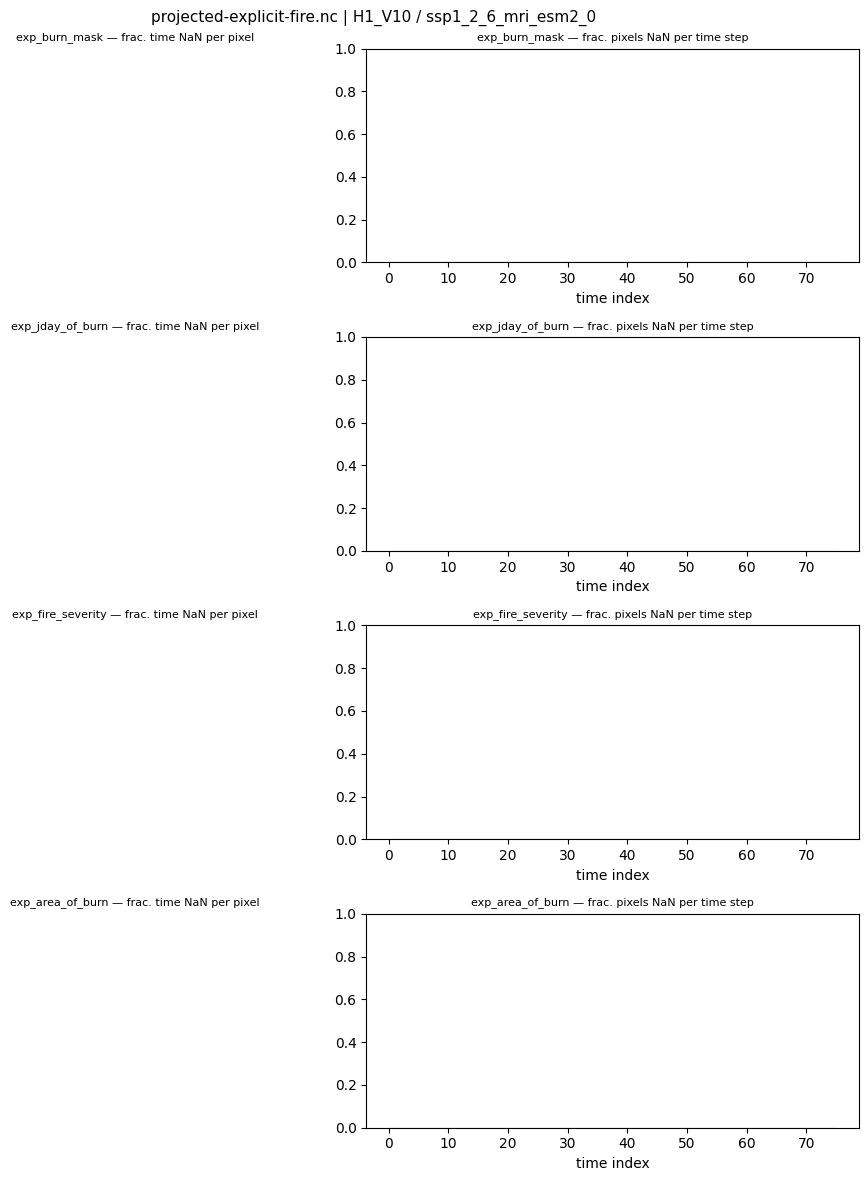

In [21]:
grid = EDA_GRIDS[0]
scenario = SCENARIOS[0]

for fname in DYN_SPAT_FILES:
    try:
        ds = open_nc(input_gcs_path(grid, scenario, fname))
        time_vars = [v for v in ds.data_vars if "time" in ds[v].dims]
        if not time_vars:
            print(f"{fname}: no time-dimensioned variables, skipping.")
            continue

        n_vars = len(time_vars)
        fig, axes = plt.subplots(n_vars, 2, figsize=(10, 3 * max(n_vars, 1)))
        if n_vars == 1:
            axes = axes[np.newaxis, :]
        fig.suptitle(f"{fname} | {grid} / {scenario}", fontsize=11)

        for i, var in enumerate(time_vars):
            arr = ds[var].values.astype(float)
            is_nan = np.isnan(arr)

            spatial_nan = is_nan.mean(axis=0)
            while spatial_nan.ndim > 2:
                spatial_nan = spatial_nan[0]
            axes[i, 0].imshow(spatial_nan, cmap="hot_r", vmin=0, vmax=1, origin="upper")
            axes[i, 0].set_title(f"{var} — frac. time NaN per pixel", fontsize=8)
            axes[i, 0].axis("off")

            spatial_axes = tuple(range(1, is_nan.ndim))
            temp_nan = is_nan.mean(axis=spatial_axes)
            axes[i, 1].plot(temp_nan, linewidth=0.8)
            axes[i, 1].set_title(f"{var} — frac. pixels NaN per time step", fontsize=8)
            axes[i, 1].set_xlabel("time index")
            axes[i, 1].set_ylim(0, 1)

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error for {fname}: {e}")


### 5c. Targets â€” NaN Spatial Maps

Row 0 = historical (`_tr`), Row 1 = projected (`_sc`).  
Ocean pixels will appear fully NaN â€” these are dropped in preprocessing.

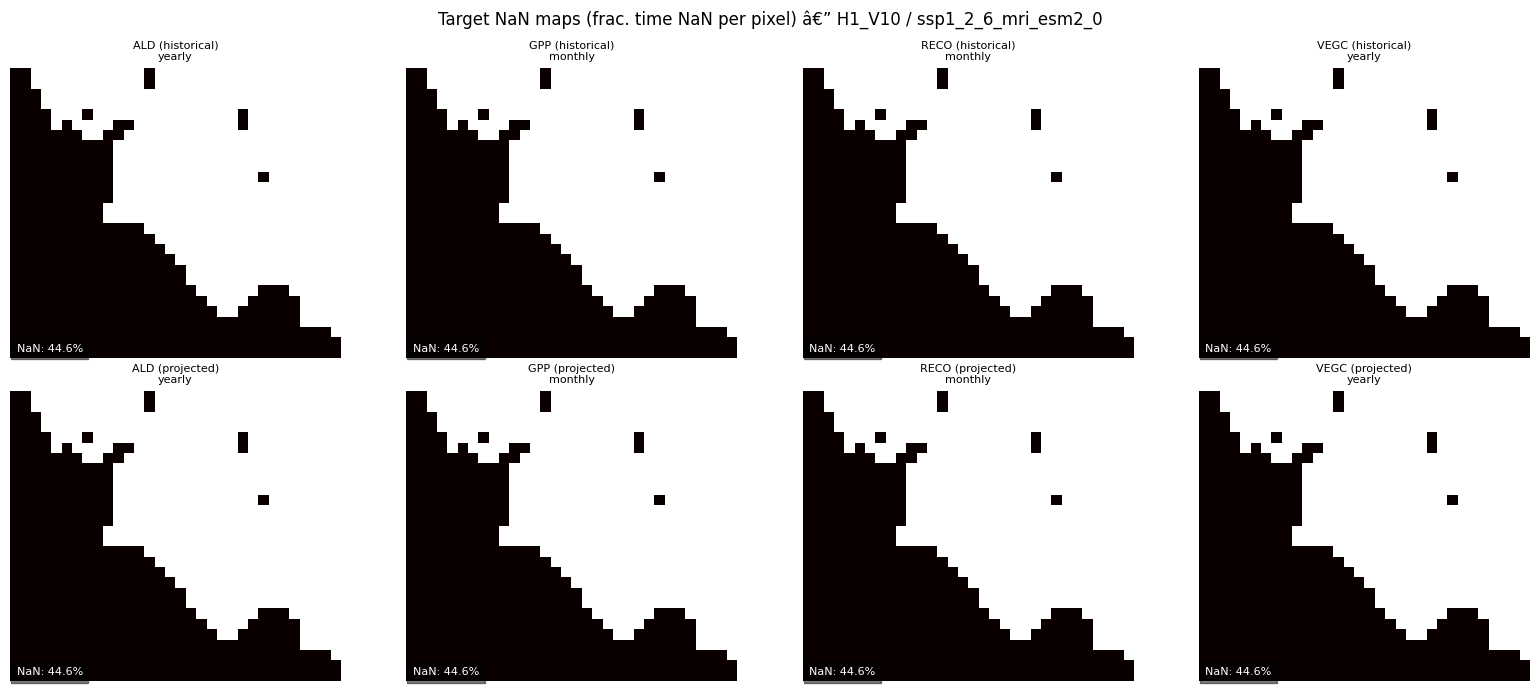

In [22]:
grid = EDA_GRIDS[0]
scenario = SCENARIOS[0]
n = len(TARGETS)

fig, axes = plt.subplots(2, n, figsize=(4 * n, 7))
fig.suptitle(f"Target NaN maps (frac. time NaN per pixel) â€” {grid} / {scenario}", fontsize=12)

for col, t in enumerate(TARGETS):
    for row, (period, fname) in enumerate([("historical", t["historical"]), ("projected", t["projected"])]):
        ax = axes[row, col]
        try:
            ds = open_nc(target_gcs_path(grid, scenario, fname))
            var = list(ds.data_vars)[0]
            arr = ds[var].values
            is_nan = np.isnan(arr)
            spatial_nan = is_nan.mean(axis=0) if arr.ndim > 2 else is_nan.astype(float)
            while spatial_nan.ndim > 2:
                spatial_nan = spatial_nan[0]
            ax.imshow(spatial_nan, cmap="hot_r", vmin=0, vmax=1, origin="upper")
            ax.set_title(f"{t['name']} ({period})\n{t['resolution']}", fontsize=8)
            ax.axis("off")
            ax.text(0.02, 0.02, f"NaN: {spatial_nan.mean():.1%}", transform=ax.transAxes,
                    fontsize=8, color="white", bbox=dict(fc="black", alpha=0.5))
        except Exception as e:
            ax.set_title(f"{t['name']} ({period})\nERROR", fontsize=8)
            print(f"  Error: {e}")

plt.tight_layout()
plt.show()

## 6. Historical â†” Projected Continuity Check

Confirm no time overlap or gap at the historical / projected join for climate and fire inputs.

In [23]:
historic_spat  = sorted(f for f in DYN_SPAT_FILES if f.startswith("historic"))
projected_spat = sorted(f for f in DYN_SPAT_FILES if f.startswith("projected"))
grid = EDA_GRIDS[0]

for scenario in SCENARIOS:
    print(f"\nScenario: {scenario}")
    for h_file, p_file in zip(historic_spat, projected_spat):
        try:
            h_ds = open_nc(input_gcs_path(grid, scenario, h_file))
            p_ds = open_nc(input_gcs_path(grid, scenario, p_file))
            h_end   = h_ds["time"].values[-1]
            p_start = p_ds["time"].values[0]
            gap = (p_start.year - h_end.year) * 12 + (p_start.month - h_end.month)
            status = "OK" if gap == 1 else f"*** GAP/OVERLAP = {gap} months ***"
            print(f"  {h_file} ends {str(h_end)[:10]} | {p_file} starts {str(p_start)[:10]} | {status}")
            if gap != 1:
                flags.append(f"FLAG: {h_file}/{p_file} ({scenario}) — gap/overlap of {gap} months at join.")
        except Exception as e:
            print(f"  Could not check {h_file}/{p_file}: {e}")



Scenario: ssp1_2_6_mri_esm2_0
  historic-climate.nc ends 2024-12-01 | projected-climate.nc starts 2025-01-01 | OK
  historic-explicit-fire.nc ends 2024-01-01 | projected-explicit-fire.nc starts 2025-01-01 | *** GAP/OVERLAP = 12 months ***

Scenario: ssp5_8_5_mri_esm2_0
  historic-climate.nc ends 2024-12-01 | projected-climate.nc starts 2025-01-01 | OK
  historic-explicit-fire.nc ends 2024-01-01 | projected-explicit-fire.nc starts 2025-01-01 | *** GAP/OVERLAP = 12 months ***


## 7. Summary Table

In [24]:
if summary_rows:
    df = pd.DataFrame(summary_rows)
    cols = [c for c in ["label", "nature", "variable", "dims", "shape",
                         "time_start", "time_end", "n_timesteps", "nan_frac"] if c in df.columns]
    df = df[cols].drop_duplicates().reset_index(drop=True)
    pd.set_option("display.max_rows", 200)
    pd.set_option("display.max_colwidth", 70)
    display(df)
else:
    print("No data collected â€” check for errors above.")

,label,nature,variable,dims,shape,time_start,time_end,n_timesteps,nan_frac
0,H1_V10 | soil-texture.nc,static,pct_clay,"('Y', 'X')","(28, 32)",NaN,NaN,NaN,0.0000
1,H1_V10 | soil-texture.nc,static,pct_silt,"('Y', 'X')","(28, 32)",NaN,NaN,NaN,0.0000
2,H1_V10 | soil-texture.nc,static,pct_sand,"('Y', 'X')","(28, 32)",NaN,NaN,NaN,0.0000
3,H1_V10 | soil-texture.nc,static,lambert_azimuthal_equal_area,(),(),NaN,NaN,NaN,NaN
4,H1_V10 | soil-texture.nc,static,lat,"('Y', 'X')","(28, 32)",NaN,NaN,NaN,0.0000
...,...,...,...,...,...,...,...,...,...
197,H1_V7 | ssp5_8_5_mri_esm2_0 | GPP (projected),target-monthly,lambert_azimuthal_equal_area,(),(),2025-01-01,2100-12-01,912.0,NaN
198,H1_V7 | ssp5_8_5_mri_esm2_0 | RECO (projected),target-monthly,RECO,"('time', 'y', 'x')","(912, 71, 31)",2025-01-01,2100-12-01,912.0,0.3258
199,H1_V7 | ssp5_8_5_mri_esm2_0 | RECO (projected),target-monthly,lambert_azimuthal_equal_area,(),(),2025-01-01,2100-12-01,912.0,NaN
200,H1_V7 | ssp5_8_5_mri_esm2_0 | VEGC (projected),target-yearly,VEGC,"('time', 'y', 'x')","(76, 71, 31)",1901-01-01,1976-01-01,76.0,0.3258


## 8. Flags & Decisions Needed

All issues detected automatically during this EDA.  
Each **FLAG** must be resolved before preprocessing begins.

In [25]:
print(f"{len(flags)} flag(s) raised:\n")
for i, flag in enumerate(flags, 1):
    print(f"{i:>2}. {flag}")

if not flags:
    print("No flags â€” data structure matches expectations. Ready for 01_preprocess.py.")

15 flag(s) raised:

 1. FLAG: co2.nc (ssp1_2_6_mri_esm2_0) has spatial dims ['year'] â€” expected time-only.
 2. FLAG: projected-co2.nc (ssp1_2_6_mri_esm2_0) has spatial dims ['year'] â€” expected time-only.
 3. FLAG: co2.nc (ssp5_8_5_mri_esm2_0) has spatial dims ['year'] â€” expected time-only.
 4. FLAG: projected-co2.nc (ssp5_8_5_mri_esm2_0) has spatial dims ['year'] â€” expected time-only.
 5. FLAG: Mixed temporal resolutions detected: {'monthly', 'yearly'}. Decision required before preprocessing.
 6. FLAG: gs://circumpolar-readonly/raw/H1_V10/ssp5_8_5_mri_esm2_0_split/all_merged/ALD_yearly_tr.nc NOT FOUND.
 7. FLAG: gs://circumpolar-readonly/raw/H1_V10/ssp5_8_5_mri_esm2_0_split/all_merged/GPP_monthly_tr.nc NOT FOUND.
 8. FLAG: gs://circumpolar-readonly/raw/H1_V10/ssp5_8_5_mri_esm2_0_split/all_merged/RECO_monthly_tr.nc NOT FOUND.
 9. FLAG: gs://circumpolar-readonly/raw/H1_V10/ssp5_8_5_mri_esm2_0_split/all_merged/VEGC_yearly_tr.nc NOT FOUND.
10. FLAG: gs://circumpolar-readonly/raw/H1

---
**After reviewing the flags above**, update `arctic_description.md` and `config/arctic_domain.yaml` as needed, then move to `01_preprocess.py`.